Geometry Generator Initialized:
  Coordinate order: ['longitude', 'latitude', 'pressure_level', 'valid_time']
  Space size: {'longitude': 37, 'latitude': 37, 'pressure_level': 10, 'valid_time': 11}
  Total grid points: 150,590

Starting GeometryGenerator Tests

Test 1: Single Point
  Shape: torch.Size([1, 4])
  Coordinates: tensor([[  0.0000,  45.0000, 500.0000,   0.5000]])
  Coordinate order: ['longitude', 'latitude', 'pressure_level', 'valid_time']

Test 2: Line (Time Series)
  Shape: torch.Size([11, 4])
  First 3 points:
tensor([[0.0000e+00, 4.5000e+01, 5.0000e+02, 0.0000e+00],
        [0.0000e+00, 4.5000e+01, 5.0000e+02, 1.0000e-01],
        [0.0000e+00, 4.5000e+01, 5.0000e+02, 2.0000e-01]])



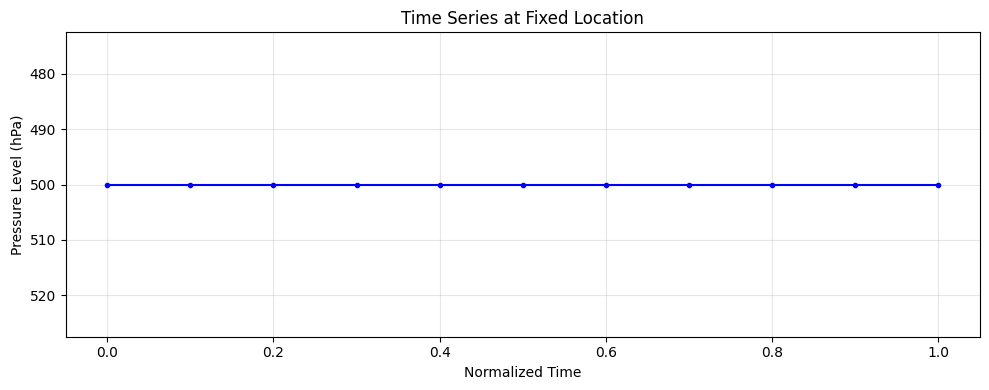

Test 3: 2D Plane (Horizontal Slice)
  Shape: torch.Size([1369, 4])
  Grid dimensions: lon=37, lat=37
  Expected total: 1369



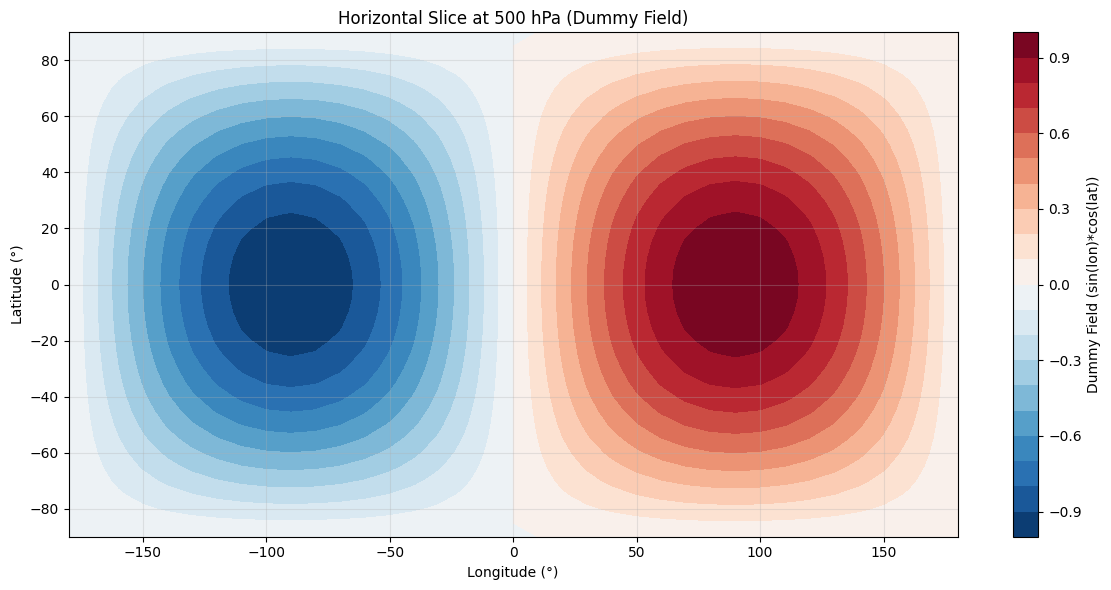

Test 4: 3D Volume
  Shape: torch.Size([13690, 4])
  Grid dimensions: {'longitude': 37, 'latitude': 37, 'pressure_level': 10}
  Expected total: 13690



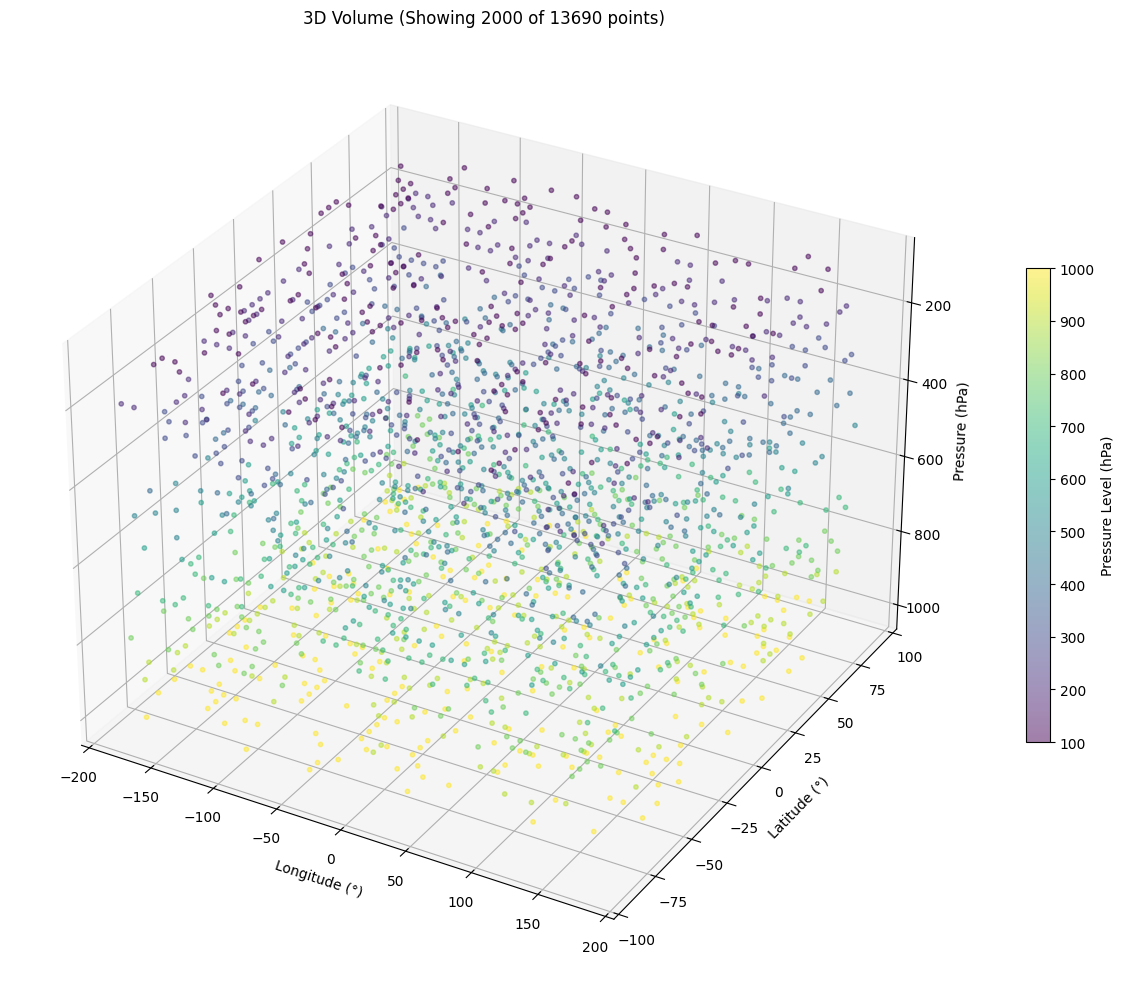

Test 5: Random Spatial Samples (Uniform)
  Shape: torch.Size([1000, 4])
  Time is fixed at: 0.5



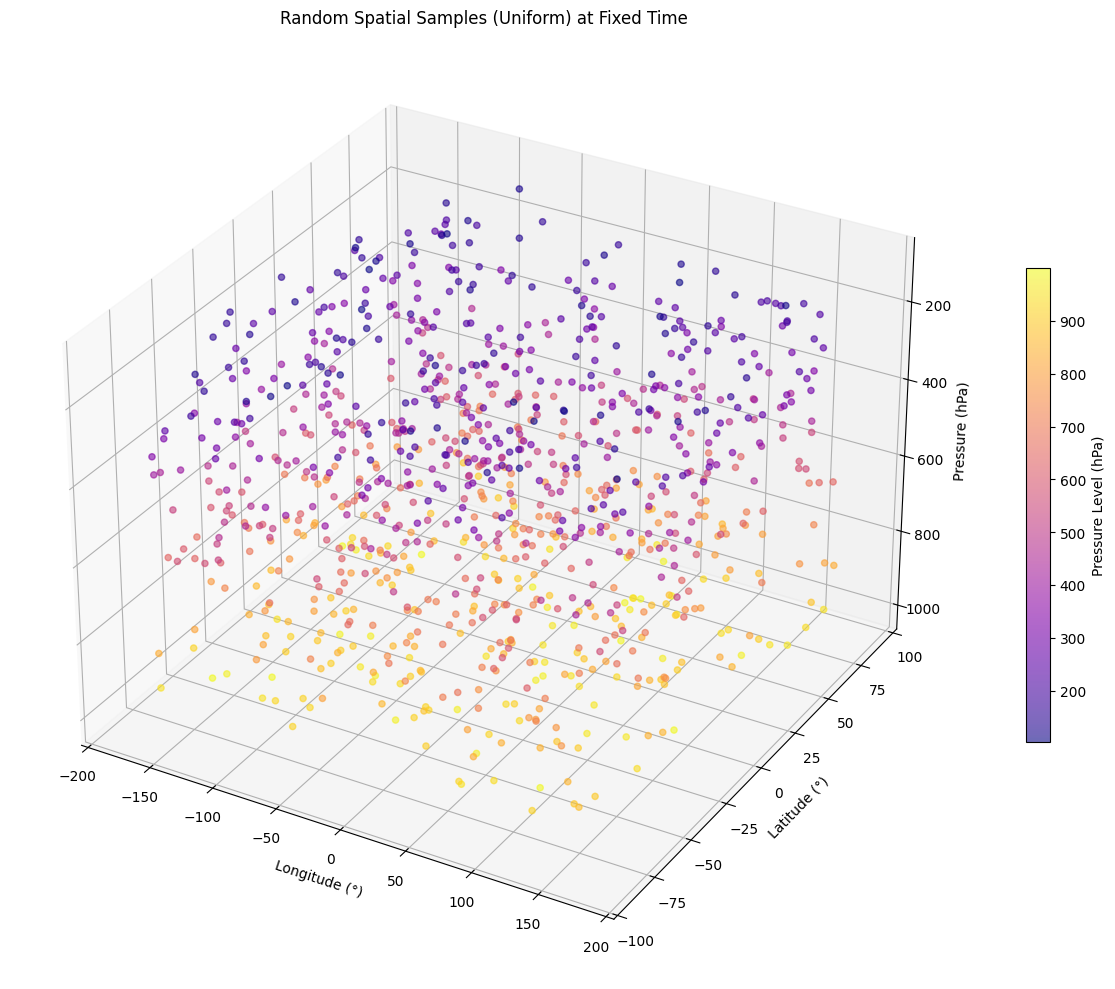

Test 6: Random Spatiotemporal Samples (LHS)
  Shape: torch.Size([1000, 4])
  Coord ranges:
    longitude: [-179.74, 179.76]
    latitude: [-89.94, 89.92]
    pressure_level: [100.04, 999.34]
    valid_time: [0.00, 1.00]



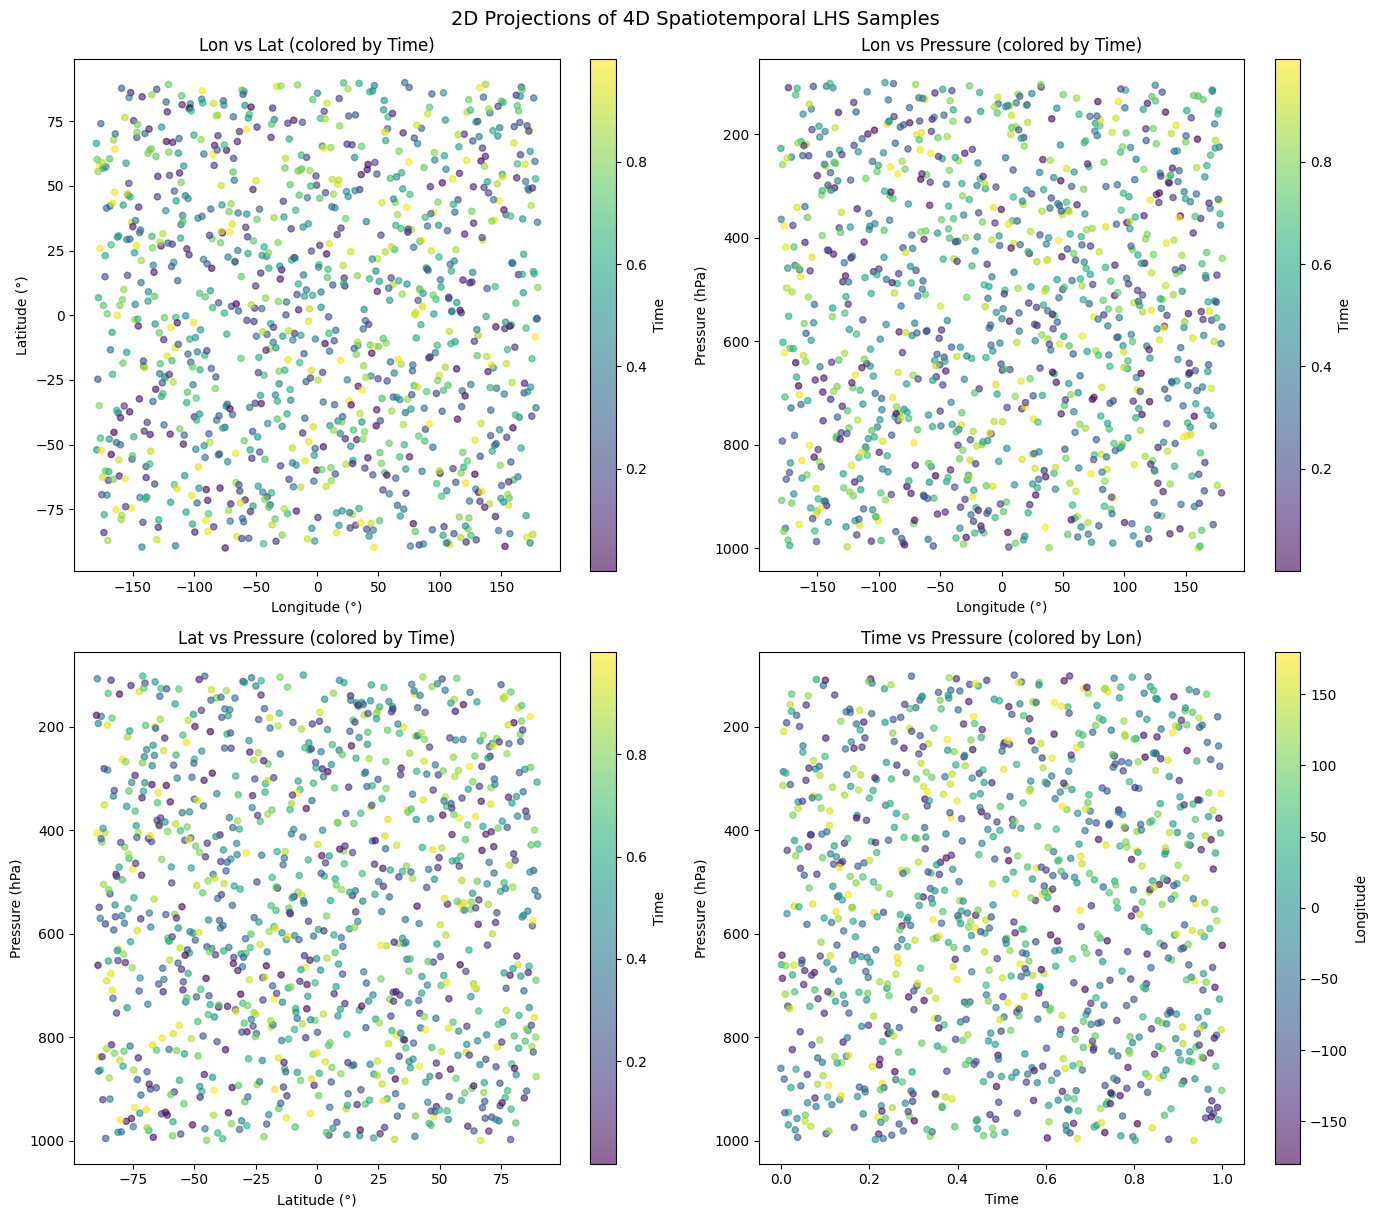

Test 7: Compute Number of Points
  Line (time): 11 points
  Plane (lon,lat): 1369 points
  Volume (lon,lat,pres): 13690 points
  Full 4D grid: 150,590 points

Test 8: Compare Sampling Methods


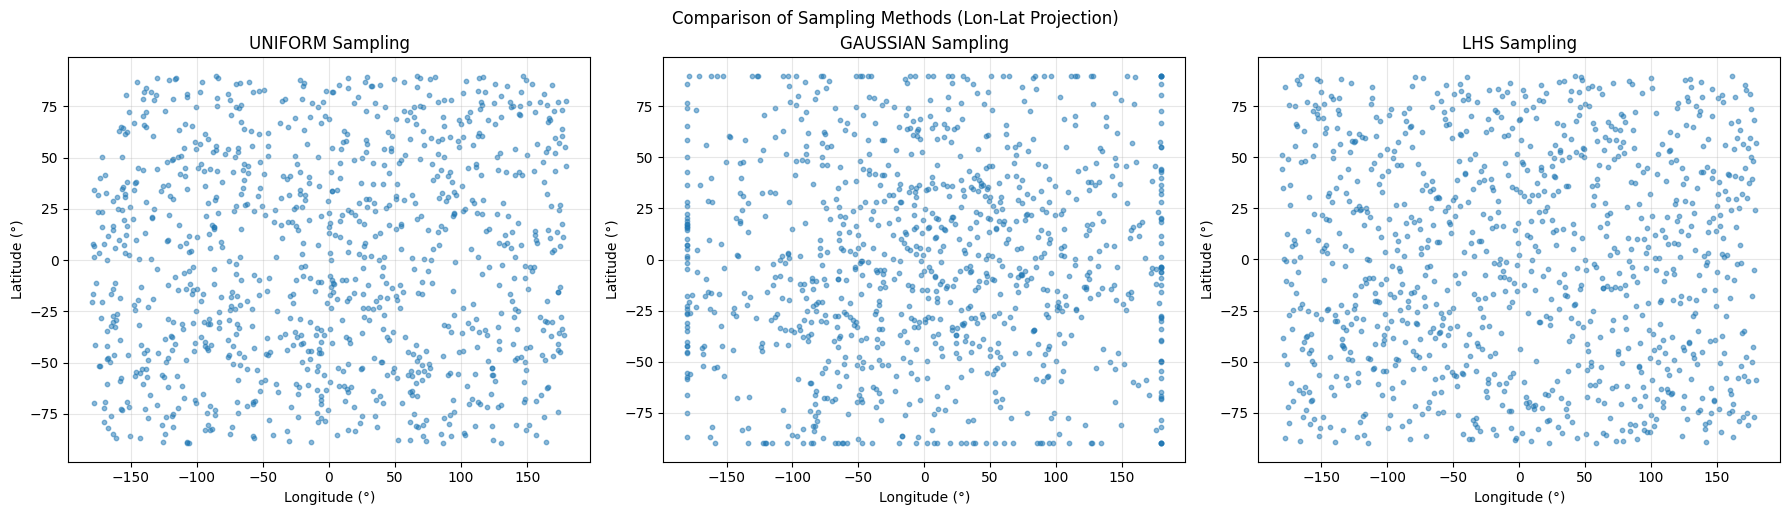


All Tests Completed Successfully!


In [1]:
# Test Notebook for GeometryGenerator

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import sys
sys.path.insert(0, r'C:\Users\micke\OneDrive - University of Toronto\geo_lab')
from geolab.viz import GeometryGenerator

# Set up the coordinate system
coord_domain = {
    'longitude': (-180, 180),
    'latitude': (-90, 90),
    'pressure_level': (100, 1000),
    'valid_time': (0, 1)
}

coord_labels = {
    'longitude': 0,
    'latitude': 1,
    'pressure_level': 2,
    'valid_time': 3
}

resolution = {
    'longitude': 10.0,
    'latitude': 5.0,
    'pressure_level': 100.0,
    'valid_time': 0.1
}

# Initialize the geometry generator
geom = GeometryGenerator(coord_domain, coord_labels, resolution)

print(f"Geometry Generator Initialized:")
print(f"  Coordinate order: {geom.coord_order}")
print(f"  Space size: {geom.space_size}")
print(f"  Total grid points: {geom.total_grid_points:,}\n")


# Test 1: Create a single point
def test_point():
    point = geom.point(
        longitude=0,
        latitude=45,
        pressure_level=500,
        valid_time=0.5
    )
    print("Test 1: Single Point")
    print(f"  Shape: {point.shape}")
    print(f"  Coordinates: {point}")
    print(f"  Coordinate order: {geom.coord_order}\n")
    return point


# Test 2: Create a line (time series at fixed location)
def test_line():
    line = geom.line(
        axis='valid_time',
        longitude=0,
        latitude=45,
        pressure_level=500
    )
    print("Test 2: Line (Time Series)")
    print(f"  Shape: {line.shape}")
    print(f"  First 3 points:\n{line[:3]}\n")

    # Plot the time series
    plt.figure(figsize=(10, 4))
    plt.plot(line[:, 3], line[:, 2], 'b-o', markersize=3)
    plt.gca().invert_yaxis()
    plt.xlabel('Normalized Time')
    plt.ylabel('Pressure Level (hPa)')
    plt.title('Time Series at Fixed Location')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return line


# Test 3: Create a 2D plane (horizontal slice)
def test_plane():
    plane = geom.plane(
        axes=['longitude', 'latitude'],
        pressure_level=500,
        valid_time=0.5
    )
    print("Test 3: 2D Plane (Horizontal Slice)")
    print(f"  Shape: {plane.shape}")

    # Get actual grid dimensions
    space_size = geom.compute_space_size(['longitude', 'latitude'])
    n_lon = space_size['longitude']
    n_lat = space_size['latitude']
    print(f"  Grid dimensions: lon={n_lon}, lat={n_lat}")
    print(f"  Expected total: {n_lon * n_lat}\n")

    # Reshape for plotting - convert to NumPy first
    lon = plane[:, 0].numpy().reshape((n_lon, n_lat))  # Add .numpy()
    lat = plane[:, 1].numpy().reshape((n_lon, n_lat))  # Add .numpy()

    # Create dummy field for visualization
    dummy_field = np.sin(np.radians(lon)) * np.cos(np.radians(lat))

    # Plot the horizontal slice
    plt.figure(figsize=(12, 6))
    plt.contourf(lon, lat, dummy_field, levels=20, cmap='RdBu_r')
    plt.colorbar(label='Dummy Field (sin(lon)*cos(lat))')
    plt.xlabel('Longitude (°)')
    plt.ylabel('Latitude (°)')
    plt.title('Horizontal Slice at 500 hPa (Dummy Field)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return plane


# Test 4: Create a 3D volume
def test_volume():
    volume = geom.volume(
        axes=['longitude', 'latitude', 'pressure_level'],
        valid_time=0.5
    )
    print("Test 4: 3D Volume")
    print(f"  Shape: {volume.shape}")

    # Get grid dimensions
    space_size = geom.compute_space_size(['longitude', 'latitude', 'pressure_level'])
    print(f"  Grid dimensions: {space_size}")
    print(f"  Expected total: {geom.compute_num_points(['longitude', 'latitude', 'pressure_level'])}\n")

    # Take a subset for visualization
    subset_indices = np.random.choice(volume.shape[0], size=min(2000, volume.shape[0]), replace=False)
    subset = volume[subset_indices]

    # 3D scatter plot
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(
        subset[:, 0],  # longitude
        subset[:, 1],  # latitude
        subset[:, 2],  # pressure
        c=subset[:, 2],  # color by pressure
        cmap='viridis',
        alpha=0.5,
        s=10
    )
    ax.invert_zaxis()
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.set_zlabel('Pressure (hPa)')
    plt.colorbar(sc, label='Pressure Level (hPa)', shrink=0.5)
    plt.title(f'3D Volume (Showing {len(subset)} of {volume.shape[0]} points)')
    plt.tight_layout()
    plt.show()

    return volume


# Test 5: Random spatial samples
def test_random_spatial_samples():
    samples = geom.random_spatial_samples(
        n_samples=1000,
        fixed_coords={'valid_time': 0.5},
        sampling_method='uniform',
        seed=42
    )
    print("Test 5: Random Spatial Samples (Uniform)")
    print(f"  Shape: {samples.shape}")
    print(f"  Time is fixed at: {samples[0, 3]:.1f}\n")

    # 3D scatter plot
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(
        samples[:, 0],  # longitude
        samples[:, 1],  # latitude
        samples[:, 2],  # pressure
        c=samples[:, 2],  # color by pressure
        cmap='plasma',
        alpha=0.6,
        s=20
    )
    ax.invert_zaxis()
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.set_zlabel('Pressure (hPa)')
    plt.colorbar(sc, label='Pressure Level (hPa)', shrink=0.5)
    plt.title('Random Spatial Samples (Uniform) at Fixed Time')
    plt.tight_layout()
    plt.show()

    return samples


# Test 6: Random spatiotemporal samples
def test_random_spatiotemporal_samples():
    samples = geom.random_spatiotemporal_samples(
        n_samples=1000,
        use_lhs=True,
        seed=42
    )
    print("Test 6: Random Spatiotemporal Samples (LHS)")
    print(f"  Shape: {samples.shape}")
    print(f"  Coord ranges:")
    for i, coord in enumerate(geom.coord_order):
        print(f"    {coord}: [{samples[:, i].min():.2f}, {samples[:, i].max():.2f}]")
    print()

    # Create a 2x2 grid of subplots
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    # Longitude vs Latitude
    sc1 = axs[0, 0].scatter(
        samples[:, 0], samples[:, 1],
        c=samples[:, 3], cmap='viridis', alpha=0.6, s=20
    )
    axs[0, 0].set_xlabel('Longitude (°)')
    axs[0, 0].set_ylabel('Latitude (°)')
    axs[0, 0].set_title('Lon vs Lat (colored by Time)')
    plt.colorbar(sc1, ax=axs[0, 0], label='Time')

    # Longitude vs Pressure
    sc2 = axs[0, 1].scatter(
        samples[:, 0], samples[:, 2],
        c=samples[:, 3], cmap='viridis', alpha=0.6, s=20
    )
    axs[0, 1].set_xlabel('Longitude (°)')
    axs[0, 1].set_ylabel('Pressure (hPa)')
    axs[0, 1].set_title('Lon vs Pressure (colored by Time)')
    axs[0, 1].invert_yaxis()
    plt.colorbar(sc2, ax=axs[0, 1], label='Time')

    # Latitude vs Pressure
    sc3 = axs[1, 0].scatter(
        samples[:, 1], samples[:, 2],
        c=samples[:, 3], cmap='viridis', alpha=0.6, s=20
    )
    axs[1, 0].set_xlabel('Latitude (°)')
    axs[1, 0].set_ylabel('Pressure (hPa)')
    axs[1, 0].set_title('Lat vs Pressure (colored by Time)')
    axs[1, 0].invert_yaxis()
    plt.colorbar(sc3, ax=axs[1, 0], label='Time')

    # Time vs Pressure
    sc4 = axs[1, 1].scatter(
        samples[:, 3], samples[:, 2],
        c=samples[:, 0], cmap='viridis', alpha=0.6, s=20
    )
    axs[1, 1].set_xlabel('Time')
    axs[1, 1].set_ylabel('Pressure (hPa)')
    axs[1, 1].set_title('Time vs Pressure (colored by Lon)')
    axs[1, 1].invert_yaxis()
    plt.colorbar(sc4, ax=axs[1, 1], label='Longitude')

    plt.tight_layout()
    plt.suptitle('2D Projections of 4D Spatiotemporal LHS Samples', y=1.01, fontsize=14)
    plt.show()

    return samples


# Test 7: Compute number of points
def test_compute_num_points():
    print("Test 7: Compute Number of Points")
    print(f"  Line (time): {geom.compute_num_points(['valid_time'])} points")
    print(f"  Plane (lon,lat): {geom.compute_num_points(['longitude', 'latitude'])} points")
    print(f"  Volume (lon,lat,pres): {geom.compute_num_points(['longitude', 'latitude', 'pressure_level'])} points")
    print(f"  Full 4D grid: {geom.total_grid_points:,} points\n")


# Test 8: Compare sampling methods
def test_compare_sampling_methods():
    print("Test 8: Compare Sampling Methods")

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    for idx, method in enumerate(['uniform', 'gaussian', 'lhs']):
        samples = geom.random_spatial_samples(
            n_samples=1000,
            fixed_coords={'valid_time': 0.5},
            sampling_method=method,
            seed=42
        )

        axs[idx].scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10)
        axs[idx].set_xlabel('Longitude (°)')
        axs[idx].set_ylabel('Latitude (°)')
        axs[idx].set_title(f'{method.upper()} Sampling')
        axs[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Comparison of Sampling Methods (Lon-Lat Projection)', y=1.02)
    plt.show()


# Run all tests
def run_all_tests():
    print("=" * 60)
    print("Starting GeometryGenerator Tests")
    print("=" * 60 + "\n")

    # Run each test
    point = test_point()
    line = test_line()
    plane = test_plane()
    volume = test_volume()
    random_spatial = test_random_spatial_samples()
    random_spatiotemporal = test_random_spatiotemporal_samples()
    test_compute_num_points()
    test_compare_sampling_methods()

    print("\n" + "=" * 60)
    print("All Tests Completed Successfully!")
    print("=" * 60)

    return {
        'point': point,
        'line': line,
        'plane': plane,
        'volume': volume,
        'random_spatial': random_spatial,
        'random_spatiotemporal': random_spatiotemporal
    }


# Run all tests
results = run_all_tests()